In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,f1_score,recall_score,confusion_matrix


In [2]:
main_df = pd.read_csv("/Users/utkuseyithanoglu/Desktop/nyc car crash analysis/data/raw/clean_crash_data.csv")

In [3]:
main_df.head()

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,...,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,CONTRIBUTING FACTOR VEHICLE 1,COLLISION_ID,day_of_week,is_weekend,hour,injury_flag,vehicle_category
0,2023-11-01,1:29,BROOKLYN,11230,40.621790,-73.970024,1.0,0.0,0,0,...,0,1,0,Unspecified,4675373,2,0,1,1,Other
1,2021-09-11,9:35,BROOKLYN,11208,40.667202,-73.866500,0.0,0.0,0,0,...,0,0,0,Unspecified,4456314,5,1,9,0,Car
2,2021-12-14,8:13,BROOKLYN,11233,40.683304,-73.917274,0.0,0.0,0,0,...,0,0,0,Unspecified,4486609,1,0,8,0,Other
3,2021-12-14,17:05,UNKNOWN,0,40.709183,-73.956825,0.0,0.0,0,0,...,0,0,0,Passing Too Closely,4486555,1,0,17,0,Car
4,2021-12-14,8:17,BRONX,10475,40.868160,-73.831480,2.0,0.0,0,0,...,0,2,0,Unspecified,4486660,1,0,8,1,Car


In [4]:
main_df.isna().sum()

CRASH DATE                       0
CRASH TIME                       0
BOROUGH                          0
ZIP CODE                         0
LATITUDE                         0
LONGITUDE                        0
NUMBER OF PERSONS INJURED        0
NUMBER OF PERSONS KILLED         0
NUMBER OF PEDESTRIANS INJURED    0
NUMBER OF PEDESTRIANS KILLED     0
NUMBER OF CYCLIST INJURED        0
NUMBER OF CYCLIST KILLED         0
NUMBER OF MOTORIST INJURED       0
NUMBER OF MOTORIST KILLED        0
CONTRIBUTING FACTOR VEHICLE 1    0
COLLISION_ID                     0
day_of_week                      0
is_weekend                       0
hour                             0
injury_flag                      0
vehicle_category                 0
dtype: int64

In [5]:
top10 = main_df['CONTRIBUTING FACTOR VEHICLE 1'].value_counts().nlargest(10).index
top10=top10.drop("Unspecified")
def factor(x):
    if x in top10:
        return 1
    elif x=="Unspecified":
        return 0
    else:
        return 0
    



In [6]:
main_df['CONTRIBUTING FACTOR VEHICLE 1'] = main_df['CONTRIBUTING FACTOR VEHICLE 1'].apply(factor)

In [7]:
main_df['CONTRIBUTING FACTOR VEHICLE 1'].value_counts()

CONTRIBUTING FACTOR VEHICLE 1
0    1038177
1     998220
Name: count, dtype: int64

In [8]:
main_df.head()

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,...,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,CONTRIBUTING FACTOR VEHICLE 1,COLLISION_ID,day_of_week,is_weekend,hour,injury_flag,vehicle_category
0,2023-11-01,1:29,BROOKLYN,11230,40.621790,-73.970024,1.0,0.0,0,0,...,0,1,0,0,4675373,2,0,1,1,Other
1,2021-09-11,9:35,BROOKLYN,11208,40.667202,-73.866500,0.0,0.0,0,0,...,0,0,0,0,4456314,5,1,9,0,Car
2,2021-12-14,8:13,BROOKLYN,11233,40.683304,-73.917274,0.0,0.0,0,0,...,0,0,0,0,4486609,1,0,8,0,Other
3,2021-12-14,17:05,UNKNOWN,0,40.709183,-73.956825,0.0,0.0,0,0,...,0,0,0,1,4486555,1,0,17,0,Car
4,2021-12-14,8:17,BRONX,10475,40.868160,-73.831480,2.0,0.0,0,0,...,0,2,0,0,4486660,1,0,8,1,Car


In [9]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2036397 entries, 0 to 2036396
Data columns (total 21 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   CRASH DATE                     object 
 1   CRASH TIME                     object 
 2   BOROUGH                        object 
 3   ZIP CODE                       int64  
 4   LATITUDE                       float64
 5   LONGITUDE                      float64
 6   NUMBER OF PERSONS INJURED      float64
 7   NUMBER OF PERSONS KILLED       float64
 8   NUMBER OF PEDESTRIANS INJURED  int64  
 9   NUMBER OF PEDESTRIANS KILLED   int64  
 10  NUMBER OF CYCLIST INJURED      int64  
 11  NUMBER OF CYCLIST KILLED       int64  
 12  NUMBER OF MOTORIST INJURED     int64  
 13  NUMBER OF MOTORIST KILLED      int64  
 14  CONTRIBUTING FACTOR VEHICLE 1  int64  
 15  COLLISION_ID                   int64  
 16  day_of_week                    int64  
 17  is_weekend                     int64  
 18  ho

In [10]:
main_df["CRASH TIME"] = pd.to_datetime(main_df["CRASH TIME"], format="%H:%M")

In [11]:
main_df['hour'] = main_df['CRASH TIME'].dt.hour

In [12]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2036397 entries, 0 to 2036396
Data columns (total 21 columns):
 #   Column                         Dtype         
---  ------                         -----         
 0   CRASH DATE                     object        
 1   CRASH TIME                     datetime64[ns]
 2   BOROUGH                        object        
 3   ZIP CODE                       int64         
 4   LATITUDE                       float64       
 5   LONGITUDE                      float64       
 6   NUMBER OF PERSONS INJURED      float64       
 7   NUMBER OF PERSONS KILLED       float64       
 8   NUMBER OF PEDESTRIANS INJURED  int64         
 9   NUMBER OF PEDESTRIANS KILLED   int64         
 10  NUMBER OF CYCLIST INJURED      int64         
 11  NUMBER OF CYCLIST KILLED       int64         
 12  NUMBER OF MOTORIST INJURED     int64         
 13  NUMBER OF MOTORIST KILLED      int64         
 14  CONTRIBUTING FACTOR VEHICLE 1  int64         
 15  COLLISION_ID   

In [13]:
main_df = main_df.drop(columns=['CRASH TIME'])

In [14]:
main_df['vehicle_category'].value_counts()

vehicle_category
Car      1084699
SUV       631666
Other     199984
Truck     120048
Name: count, dtype: int64

In [15]:
main_df['BOROUGH']=main_df['BOROUGH'].map({"BRONX": 0,"BROOKLYN": 1,"MANHATTAN": 2,"QUEENS": 3,
    "STATEN ISLAND": 4,
    "UNKNOWN": 5
})

In [16]:
main_df['BOROUGH']

0          1
1          1
2          1
3          5
4          0
          ..
2036392    0
2036393    5
2036394    2
2036395    5
2036396    5
Name: BOROUGH, Length: 2036397, dtype: int64

In [17]:
main_df['vehicle_category'] = main_df['vehicle_category'].map({"Car":0,"SUV":1,"Other":2,"Truck":3})

In [18]:
main_df.isna().sum()

CRASH DATE                       0
BOROUGH                          0
ZIP CODE                         0
LATITUDE                         0
LONGITUDE                        0
NUMBER OF PERSONS INJURED        0
NUMBER OF PERSONS KILLED         0
NUMBER OF PEDESTRIANS INJURED    0
NUMBER OF PEDESTRIANS KILLED     0
NUMBER OF CYCLIST INJURED        0
NUMBER OF CYCLIST KILLED         0
NUMBER OF MOTORIST INJURED       0
NUMBER OF MOTORIST KILLED        0
CONTRIBUTING FACTOR VEHICLE 1    0
COLLISION_ID                     0
day_of_week                      0
is_weekend                       0
hour                             0
injury_flag                      0
vehicle_category                 0
dtype: int64

In [19]:
main_df.head()

,CRASH DATE,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,NUMBER OF CYCLIST INJURED,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,CONTRIBUTING FACTOR VEHICLE 1,COLLISION_ID,day_of_week,is_weekend,hour,injury_flag,vehicle_category
0,2023-11-01,1,11230,40.621790,-73.970024,1.0,0.0,0,0,0,0,1,0,0,4675373,2,0,1,1,2
1,2021-09-11,1,11208,40.667202,-73.866500,0.0,0.0,0,0,0,0,0,0,0,4456314,5,1,9,0,0
2,2021-12-14,1,11233,40.683304,-73.917274,0.0,0.0,0,0,0,0,0,0,0,4486609,1,0,8,0,2
3,2021-12-14,5,0,40.709183,-73.956825,0.0,0.0,0,0,0,0,0,0,1,4486555,1,0,17,0,0
4,2021-12-14,0,10475,40.868160,-73.831480,2.0,0.0,0,0,0,0,2,0,0,4486660,1,0,8,1,0


In [20]:
main_df = main_df.drop(columns=['CRASH DATE','COLLISION_ID'])

In [21]:
main_df

,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,NUMBER OF CYCLIST INJURED,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,CONTRIBUTING FACTOR VEHICLE 1,day_of_week,is_weekend,hour,injury_flag,vehicle_category
0,1,11230,40.621790,-73.970024,1.0,0.0,0,0,0,0,1,0,0,2,0,1,1,2
1,1,11208,40.667202,-73.866500,0.0,0.0,0,0,0,0,0,0,0,5,1,9,0,0
2,1,11233,40.683304,-73.917274,0.0,0.0,0,0,0,0,0,0,0,1,0,8,0,2
3,5,0,40.709183,-73.956825,0.0,0.0,0,0,0,0,0,0,1,1,0,17,0,0
4,0,10475,40.868160,-73.831480,2.0,0.0,0,0,0,0,2,0,0,1,0,8,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2036392,0,10453,40.854816,-73.911500,3.0,0.0,0,0,0,0,3,0,1,1,0,12,1,2
2036393,5,0,40.665520,-73.744670,0.0,0.0,0,0,0,0,0,0,1,1,0,19,0,1
2036394,2,10002,40.721798,-73.988240,0.0,0.0,0,0,0,0,0,0,0,5,1,23,0,1
2036395,5,0,40.834114,-73.863270,2.0,0.0,0,0,0,0,2,0,1,1,0,22,1,1


<Axes: xlabel='BOROUGH', ylabel='injury_flag'>

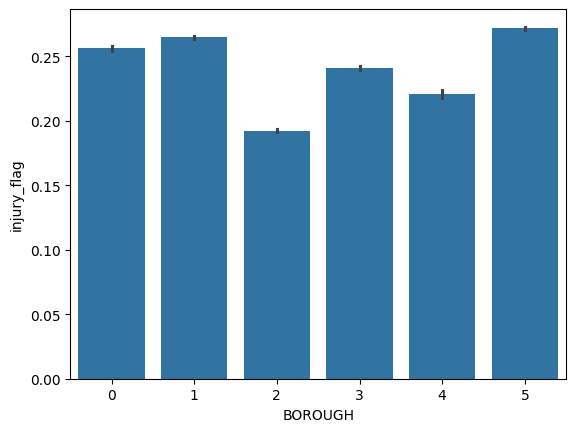

In [22]:
sns.barplot(data=main_df,x='BOROUGH',y='injury_flag')

<Axes: xlabel='injury_flag', ylabel='vehicle_category'>

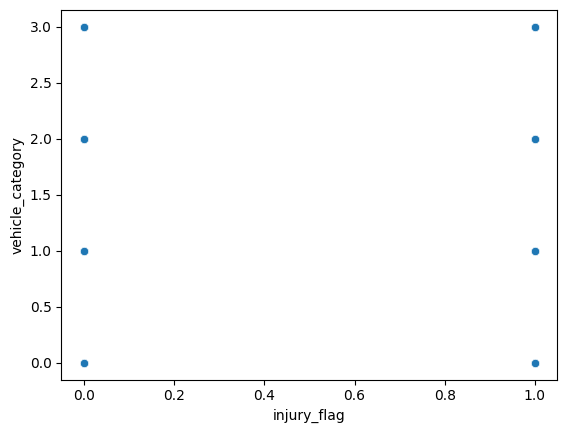

In [23]:
sns.scatterplot(data=main_df,x='injury_flag',y='vehicle_category')

In [24]:
main_df.isna().sum()

BOROUGH                          0
ZIP CODE                         0
LATITUDE                         0
LONGITUDE                        0
NUMBER OF PERSONS INJURED        0
NUMBER OF PERSONS KILLED         0
NUMBER OF PEDESTRIANS INJURED    0
NUMBER OF PEDESTRIANS KILLED     0
NUMBER OF CYCLIST INJURED        0
NUMBER OF CYCLIST KILLED         0
NUMBER OF MOTORIST INJURED       0
NUMBER OF MOTORIST KILLED        0
CONTRIBUTING FACTOR VEHICLE 1    0
day_of_week                      0
is_weekend                       0
hour                             0
injury_flag                      0
vehicle_category                 0
dtype: int64

In [25]:
main_df=main_df.drop(columns=[
    "NUMBER OF PERSONS INJURED",
    "NUMBER OF PERSONS KILLED",
    "NUMBER OF PEDESTRIANS INJURED",
    "NUMBER OF PEDESTRIANS KILLED",
    "NUMBER OF CYCLIST INJURED",
    "NUMBER OF CYCLIST KILLED",
    "NUMBER OF MOTORIST INJURED",
    "NUMBER OF MOTORIST KILLED"])

In [26]:
train_df,test_df = train_test_split(main_df,random_state=46)

In [27]:
train_df.isna().sum()

BOROUGH                          0
ZIP CODE                         0
LATITUDE                         0
LONGITUDE                        0
CONTRIBUTING FACTOR VEHICLE 1    0
day_of_week                      0
is_weekend                       0
hour                             0
injury_flag                      0
vehicle_category                 0
dtype: int64

In [28]:
test_df.isna().sum()

BOROUGH                          0
ZIP CODE                         0
LATITUDE                         0
LONGITUDE                        0
CONTRIBUTING FACTOR VEHICLE 1    0
day_of_week                      0
is_weekend                       0
hour                             0
injury_flag                      0
vehicle_category                 0
dtype: int64

In [29]:
x_train = train_df.drop(columns=['injury_flag'])
x_test = test_df.drop(columns=['injury_flag'])


In [30]:
y_train = train_df['injury_flag']
y_test = test_df['injury_flag']


In [31]:
y_train

863705     0
413773     0
1528850    0
6803       0
1990456    0
          ..
84410      1
580980     0
292392     0
1006405    0
605373     1
Name: injury_flag, Length: 1527297, dtype: int64

In [32]:
x_train

,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,CONTRIBUTING FACTOR VEHICLE 1,day_of_week,is_weekend,hour,vehicle_category
863705,5,0,40.732136,-73.919014,1,6,1,13,1
413773,0,10464,40.840702,-73.784070,0,3,0,10,2
1528850,3,11362,40.760561,-73.728815,1,1,0,10,1
6803,1,11213,40.668120,-73.928420,1,3,0,16,0
1990456,3,11412,40.691936,-73.753160,0,1,0,18,1
...,...,...,...,...,...,...,...,...,...
84410,1,11220,40.643986,-74.011490,0,3,0,11,0
580980,2,10016,40.748302,-73.978350,1,0,0,19,1
292392,2,10035,40.805737,-73.940650,0,6,1,21,0
1006405,5,0,40.680225,-74.004810,1,2,0,9,1


In [33]:
from sklearn.ensemble import RandomForestClassifier

In [34]:
rf_model = RandomForestClassifier(class_weight="balanced")
rf_model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [35]:


def model_evaluator(X, y, model):
    preds = model.predict(X)

    print("accuracy:", accuracy_score(y, preds))
    print("f1:", f1_score(y, preds))
    print("recall:", recall_score(y, preds))
    print(classification_report(y, preds))
    print(confusion_matrix(y,preds))

In [36]:
model_evaluator(x_train, y_train, rf_model)

accuracy: 0.9889648182377101
f1: 0.9779732343562131
recall: 0.9921114316624594
              precision    recall  f1-score   support

           0       1.00      0.99      0.99   1150169
           1       0.96      0.99      0.98    377128

    accuracy                           0.99   1527297
   macro avg       0.98      0.99      0.99   1527297
weighted avg       0.99      0.99      0.99   1527297

[[1136290   13879]
 [   2975  374153]]


In [37]:
model_evaluator(x_test, y_test, rf_model)

accuracy: 0.7228481634256532
f1: 0.1827796311741266
recall: 0.1257912275387044
              precision    recall  f1-score   support

           0       0.76      0.92      0.83    383662
           1       0.33      0.13      0.18    125438

    accuracy                           0.72    509100
   macro avg       0.55      0.52      0.51    509100
weighted avg       0.66      0.72      0.67    509100

[[352223  31439]
 [109659  15779]]


In [38]:
y_prob = rf_model.predict_proba(x_test)[:,1]

In [39]:
y_prob

array([0.04      , 0.07      , 0.23      , ..., 0.17      , 0.16753075,
       0.34901472], shape=(509100,))

In [40]:
y_pred = (y_prob >= 0.3).astype(int)

In [41]:


print("accuracy:", accuracy_score(y_test, y_pred))
print("f1:", f1_score(y_test, y_pred))
print("recall:", recall_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

accuracy: 0.6211314083677077
f1: 0.3349997241835834
recall: 0.3873068767040291
              precision    recall  f1-score   support

           0       0.78      0.70      0.74    383662
           1       0.30      0.39      0.33    125438

    accuracy                           0.62    509100
   macro avg       0.54      0.54      0.54    509100
weighted avg       0.66      0.62      0.64    509100

[[267635 116027]
 [ 76855  48583]]


In [42]:
y_pred = (y_prob >= 0.35).astype(int)

In [43]:


print("accuracy:", accuracy_score(y_test, y_pred))
print("f1:", f1_score(y_test, y_pred))
print("recall:", recall_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

accuracy: 0.6587310940876056
f1: 0.3044278965489631
recall: 0.30309794480141583
              precision    recall  f1-score   support

           0       0.77      0.78      0.77    383662
           1       0.31      0.30      0.30    125438

    accuracy                           0.66    509100
   macro avg       0.54      0.54      0.54    509100
weighted avg       0.66      0.66      0.66    509100

[[297340  86322]
 [ 87418  38020]]


In [44]:
y_pred = (y_prob >= 0.28).astype(int)

In [45]:


print("accuracy:", accuracy_score(y_test, y_pred))
print("f1:", f1_score(y_test, y_pred))
print("recall:", recall_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

accuracy: 0.6041131408367708
f1: 0.3468217084410913
recall: 0.42656930116870484
              precision    recall  f1-score   support

           0       0.78      0.66      0.72    383662
           1       0.29      0.43      0.35    125438

    accuracy                           0.60    509100
   macro avg       0.54      0.54      0.53    509100
weighted avg       0.66      0.60      0.63    509100

[[254046 129616]
 [ 71930  53508]]


In [46]:
y_pred = (y_prob >= 0.24).astype(int)

In [47]:


print("accuracy:", accuracy_score(y_test, y_pred))
print("f1:", f1_score(y_test, y_pred))
print("recall:", recall_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

accuracy: 0.5636279709290906
f1: 0.36601019945150126
recall: 0.5112246687606626
              precision    recall  f1-score   support

           0       0.78      0.58      0.67    383662
           1       0.29      0.51      0.37    125438

    accuracy                           0.56    509100
   macro avg       0.53      0.55      0.52    509100
weighted avg       0.66      0.56      0.59    509100

[[222816 160846]
 [ 61311  64127]]


In [48]:
np.round(pd.DataFrame(rf_model.feature_importances_,rf_model.feature_names_in_)*100,2).sort_values(by=0,ascending=False)

,0
LONGITUDE,35.08
LATITUDE,34.36
hour,12.06
day_of_week,8.13
ZIP CODE,4.54
vehicle_category,3.37
CONTRIBUTING FACTOR VEHICLE 1,1.38
is_weekend,0.73
BOROUGH,0.35


In [49]:
hyperparameters_dict = {
    "criterion" : ['gini','entropy'],
    "n_estimators": [35,50],
    "max_depth": [2,5],
    "min_samples_split": [2,5],
    "min_samples_leaf": [1,2]
}
    

In [50]:
from sklearn.model_selection import GridSearchCV

In [51]:
GridSearchCVm = GridSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced'),
    param_grid=hyperparameters_dict,
    scoring="f1",
    verbose=3

)

In [52]:
GridSearchCVm.fit(x_train,y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV 1/5] END criterion=gini, max_depth=2, min_samples_leaf=1, min_samples_split=2, n_estimators=35;, score=0.374 total time=   6.2s
[CV 2/5] END criterion=gini, max_depth=2, min_samples_leaf=1, min_samples_split=2, n_estimators=35;, score=0.376 total time=   6.3s
[CV 3/5] END criterion=gini, max_depth=2, min_samples_leaf=1, min_samples_split=2, n_estimators=35;, score=0.384 total time=   6.1s
[CV 4/5] END criterion=gini, max_depth=2, min_samples_leaf=1, min_samples_split=2, n_estimators=35;, score=0.375 total time=   6.2s
[CV 5/5] END criterion=gini, max_depth=2, min_samples_leaf=1, min_samples_split=2, n_estimators=35;, score=0.361 total time=   6.2s
[CV 1/5] END criterion=gini, max_depth=2, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.382 total time=   8.8s
[CV 2/5] END criterion=gini, max_depth=2, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.386 total time=   8.9s
[CV 3/5] END c

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ht='balanced')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [2, 5], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter 

In [53]:
model_evaluator(x_train, y_train,GridSearchCVm)

accuracy: 0.5613446500582402
f1: 0.3849108017513723
recall: 0.5558404573513502
              precision    recall  f1-score   support

           0       0.79      0.56      0.66   1150169
           1       0.29      0.56      0.38    377128

    accuracy                           0.56   1527297
   macro avg       0.54      0.56      0.52   1527297
weighted avg       0.67      0.56      0.59   1527297

[[647717 502452]
 [167505 209623]]


In [54]:
model_evaluator(x_test, y_test,GridSearchCVm)

accuracy: 0.5614103319583579
f1: 0.38401483091760785
recall: 0.55485578532821
              precision    recall  f1-score   support

           0       0.79      0.56      0.66    383662
           1       0.29      0.55      0.38    125438

    accuracy                           0.56    509100
   macro avg       0.54      0.56      0.52    509100
weighted avg       0.67      0.56      0.59    509100

[[216214 167448]
 [ 55838  69600]]


In [55]:
pd.Series(
    GridSearchCVm.best_estimator_.feature_importances_,
    index=x_test.columns).sort_values(ascending=False)


vehicle_category                 0.299280
hour                             0.210720
LONGITUDE                        0.171263
LATITUDE                         0.140488
ZIP CODE                         0.094190
BOROUGH                          0.068561
CONTRIBUTING FACTOR VEHICLE 1    0.005960
is_weekend                       0.005193
day_of_week                      0.004345
dtype: float64

In [56]:
import pickle

with open("gridsearch_crash_model.pkl", "wb") as f:
    pickle.dump(GridSearchCVm.best_estimator_, f)

In [57]:
with open("gridsearch_crash_model.pkl", "rb") as f:
    model = pickle.load(f)

with open("model_features.pkl", "rb") as f:
    feature_cols = pickle.load(f)

x_test = x_test[feature_cols]

# ---------------------------
# 5) PREDICTIONS
# ---------------------------
pred_class = model.predict(x_test)
pred_prob = model.predict_proba(x_test)[:, 1]

# optional custom threshold from your notebook tests
threshold = 0.30
pred_class_03 = (pred_prob >= threshold).astype(int)


In [60]:
with open("rf_crash_model.pkl", "rb") as f:
    rf_model_loaded = pickle.load(f)

with open("gridsearch_crash_model.pkl", "rb") as f:
    gs_model_loaded = pickle.load(f)

with open("model_features.pkl", "rb") as f:
    feature_cols = pickle.load(f)

FileNotFoundError: [Errno 2] No such file or directory: 'rf_crash_model.pkl'

In [61]:
# ---------------------------
# LOAD EXISTING FILES
# ---------------------------
with open("gridsearch_crash_model.pkl", "rb") as f:
    gs_model_loaded = pickle.load(f)

with open("model_features.pkl", "rb") as f:
    feature_cols = pickle.load(f)

# ---------------------------
# ALIGN TEST FEATURES
# ---------------------------
x_test_aligned = x_test[feature_cols].copy()

# ---------------------------
# GRIDSEARCH PREDICTIONS
# ---------------------------
gs_pred_class = gs_model_loaded.predict(x_test_aligned)
gs_pred_prob = gs_model_loaded.predict_proba(x_test_aligned)[:, 1]

threshold = 0.30
gs_pred_class_03 = (gs_pred_prob >= threshold).astype(int)

# ---------------------------
# TABLEAU DATASET
# ---------------------------
tableau_pred_df = x_test_aligned.copy()
tableau_pred_df["actual_injury_flag"] = y_test.values
tableau_pred_df["gs_pred_class"] = gs_pred_class
tableau_pred_df["gs_pred_prob"] = gs_pred_prob
tableau_pred_df["gs_pred_class_03"] = gs_pred_class_03

borough_map_reverse = {
    0: "BRONX",
    1: "BROOKLYN",
    2: "MANHATTAN",
    3: "QUEENS",
    4: "STATEN ISLAND",
    5: "UNKNOWN"
}
tableau_pred_df["BOROUGH_NAME"] = tableau_pred_df["BOROUGH"].map(borough_map_reverse)

vehicle_map_reverse = {
    0: "Car",
    1: "SUV",
    2: "Other",
    3: "Truck"
}
tableau_pred_df["vehicle_category_name"] = tableau_pred_df["vehicle_category"].map(vehicle_map_reverse)

tableau_pred_df.to_csv("tableau_gridsearch_predictions.csv", index=False)

print("CSV created successfully:", tableau_pred_df.shape)
display(tableau_pred_df.head())

CSV created successfully: (509100, 15)


,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,CONTRIBUTING FACTOR VEHICLE 1,day_of_week,is_weekend,hour,vehicle_category,actual_injury_flag,gs_pred_class,gs_pred_prob,gs_pred_class_03,BOROUGH_NAME,vehicle_category_name
1202415,3,11355,40.755486,-73.82472,1,3,0,0,1,1,0,0.478423,1,QUEENS,SUV
14410,1,11222,40.724200,-73.93765,0,1,0,16,1,1,0,0.471775,1,BROOKLYN,SUV
1494904,2,10014,40.729826,-74.01060,0,4,0,6,1,0,0,0.409222,1,MANHATTAN,SUV
899354,5,0,40.714478,-74.01354,0,1,0,11,0,0,0,0.460994,1,UNKNOWN,Car
326098,1,11226,40.650642,-73.96527,0,1,0,8,0,0,0,0.495777,1,BROOKLYN,Car


In [62]:
feature_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": gs_model_loaded.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance_df.to_csv("tableau_gridsearch_feature_importance.csv", index=False)
feature_importance_df

,feature,importance
8,vehicle_category,0.299280
7,hour,0.210720
3,LONGITUDE,0.171263
2,LATITUDE,0.140488
1,ZIP CODE,0.094190
0,BOROUGH,0.068561
4,CONTRIBUTING FACTOR VEHICLE 1,0.005960
6,is_weekend,0.005193
5,day_of_week,0.004345
